In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.operators import MeasurementOperator
from src.admm import admm_solve
from src.metrics import relative_error, psnr, ssim, print_metrics
from config import (SHEPP_LOGAN_PATH, IMAGE_SIZE, N_MEASUREMENTS,
                    RANDOM_SEED, RHO, MAX_ITER, TOL)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

In [2]:
X_true = np.load(SHEPP_LOGAN_PATH)

print(f"Shape      : {X_true.shape}")
print(f"Value range: [{X_true.min():.4f}, {X_true.max():.4f}]")
print(f"dtype      : {X_true.dtype}")

# Confirm normalised to [0,1] — required by psnr and ssim
assert X_true.min() >= 0.0 and X_true.max() <= 1.0, \
    "Image not normalised — check data/generate.py"

sigma = np.linalg.svd(X_true, compute_uv=False)

print("\nEnergy captured by top-k singular values:")
total_energy = np.sum(sigma**2)
for k in [5, 10, 20, 30, 50]:
    energy = np.sum(sigma[:k]**2) / total_energy
    print(f"  top-{k:3d} : {energy*100:.1f}%")

print(f"\nRank at different tolerances:")
for t in [1e-1, 1e-2, 1e-3]:
    print(f"  tol={t:.0e} : rank = {np.sum(sigma > t)}")

Shape      : (128, 128)
Value range: [0.0000, 1.0000]
dtype      : float64

Energy captured by top-k singular values:
  top-  5 : 77.0%
  top- 10 : 91.7%
  top- 20 : 98.8%
  top- 30 : 99.8%
  top- 50 : 100.0%

Rank at different tolerances:
  tol=1e-01 : rank = 49
  tol=1e-02 : rank = 71
  tol=1e-03 : rank = 71


In [3]:
op = MeasurementOperator(n=IMAGE_SIZE, m=N_MEASUREMENTS, seed=RANDOM_SEED)
y  = op.measure(X_true)

print(f"Sampling ratio: {N_MEASUREMENTS}/{IMAGE_SIZE**2} = "
      f"{N_MEASUREMENTS/IMAGE_SIZE**2:.4f}  ({100*N_MEASUREMENTS/IMAGE_SIZE**2:.1f}%)\n")

result = admm_solve(op, y, rho=RHO, max_iter=MAX_ITER, tol=TOL,
                    X_true=X_true, verbose=True)

Sampling ratio: 5000/16384 = 0.3052  (30.5%)

  Iter        Primal          Dual    Rank      RelErr
-------------------------------------------------------
     1     16.640665     24.960998       0    1.000000
     2     10.883693      5.127261     107    0.856087
     3      0.943856      3.703107      89    0.730259
     4      0.702909      3.029538      80    0.691718
     5      0.603189      2.564035      76    0.658305
    51      0.010382      0.043618      50    0.367163
   101      0.000262      0.001337      50    0.362542
   151      0.000010      0.000055      50    0.362407

Converged at iteration 179
Primal residual: 1.82e-06
Dual residual: 9.87e-06
Final rank: 50
Relative error: 0.362403


In [4]:
print("=" * 40)
print("Reconstruction metrics — Shepp-Logan")
print("=" * 40)
print_metrics(result.X, X_true)
print(f"\nConverged  : {result.converged}")
print(f"Iterations : {result.n_iters}")
print(f"Final rank : {np.sum(np.linalg.svd(result.X, compute_uv=False) > 1e-3)}")

Reconstruction metrics — Shepp-Logan
Relative error : 0.362403
PSNR: 21.99 dB
SSIM: 0.338579

Converged  : True
Iterations : 179
Final rank : 50


ratio=0.10  m= 1638  rel_err=0.7494  PSNR=15.5dB  SSIM=0.120
ratio=0.30  m= 4915  rel_err=0.3684  PSNR=21.8dB  SSIM=0.334
ratio=0.50  m= 8192  rel_err=0.1515  PSNR=29.8dB  SSIM=0.600


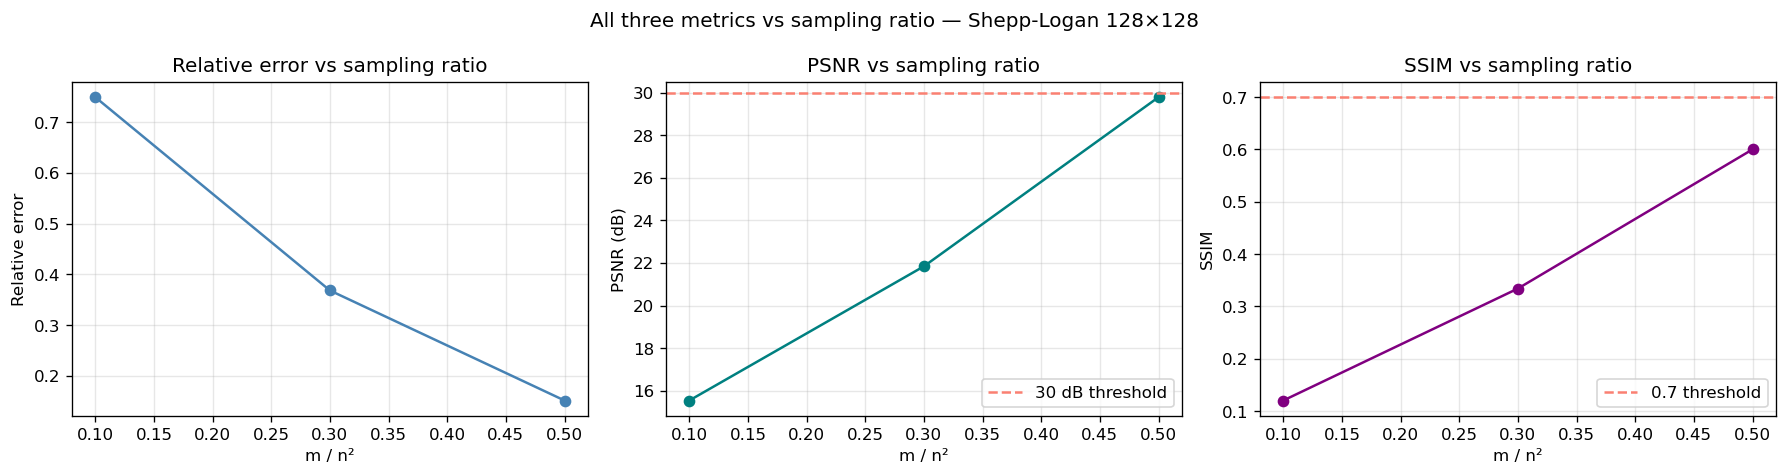

In [5]:
# How do all three metrics change as we give the solver more measurements?

ratios  = [0.1, 0.3, 0.5]
results_metrics = {'rel_err': [], 'psnr': [], 'ssim': []}

for ratio in ratios:
    m_r = max(10, int(ratio * IMAGE_SIZE**2))
    op_r = MeasurementOperator(n=IMAGE_SIZE, m=m_r, seed=RANDOM_SEED)
    y_r  = op_r.measure(X_true)
    res  = admm_solve(op_r, y_r, rho=RHO, max_iter=MAX_ITER,
                      tol=TOL, verbose=False)

    results_metrics['rel_err'].append(relative_error(res.X, X_true))
    results_metrics['psnr'].append(psnr(res.X, X_true))
    results_metrics['ssim'].append(ssim(res.X, X_true))

    print(f"ratio={ratio:.2f}  m={m_r:5d}  "
          f"rel_err={results_metrics['rel_err'][-1]:.4f}  "
          f"PSNR={results_metrics['psnr'][-1]:.1f}dB  "
          f"SSIM={results_metrics['ssim'][-1]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ratios, results_metrics['rel_err'], 'o-',
             color='steelblue', linewidth=1.5, markersize=6)
axes[0].set_title("Relative error vs sampling ratio")
axes[0].set_xlabel("m / n²")
axes[0].set_ylabel("Relative error")
axes[0].grid(True, alpha=0.3)

axes[1].plot(ratios, results_metrics['psnr'], 'o-',
             color='teal', linewidth=1.5, markersize=6)
axes[1].axhline(y=30, color='salmon', linestyle='--', label='30 dB threshold')
axes[1].set_title("PSNR vs sampling ratio")
axes[1].set_xlabel("m / n²")
axes[1].set_ylabel("PSNR (dB)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(ratios, results_metrics['ssim'], 'o-',
             color='purple', linewidth=1.5, markersize=6)
axes[2].axhline(y=0.7, color='salmon', linestyle='--', label='0.7 threshold')
axes[2].set_title("SSIM vs sampling ratio")
axes[2].set_xlabel("m / n²")
axes[2].set_ylabel("SSIM")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("All three metrics vs sampling ratio — Shepp-Logan 128×128", fontsize=12)
plt.tight_layout()
plt.show()